<a href="https://colab.research.google.com/github/kleberbarros9/digitalinnovationone/blob/bairesdev-machine_learning_training/metricas_avaliacao__mnist_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###**Acurácia, precisão, sensibilidade, especificidade e F1-score são métricas fundamentais para avaliar o desempenho de modelos de classificação em Machine Learning.**

As métricas de avaliação medem o desempenho de modelos de classificação com base nos acertos e erros em relação às classes reais.

### 🧩 Conceitos Iniciais (Matriz de Confusão)

- **VP (Verdadeiro Positivo):** Previsão correta da classe positiva.  
- **VN (Verdadeiro Negativo):** Previsão correta da classe negativa.  
- **FP (Falso Positivo):** Previsão positiva incorreta (era negativa).  
- **FN (Falso Negativo):** Previsão negativa incorreta (era positiva).

---

### 📌 Principais Métricas

#### ✅ Acurácia
> Proporção total de acertos (positivos e negativos) sobre todas as previsões.  
**Boa para:** dados balanceados.  
**Atenção:** pode ser enganosa com classes desbalanceadas.

#### 🎯 Precisão
> Entre todas as previsões positivas, quantas são realmente positivas.  
**Boa para:** evitar falsos positivos.  
**Exemplo:** diagnósticos onde alarmes falsos são problemáticos.

#### 🔍 Sensibilidade (Recall)
> Entre todas as classes realmente positivas, quantas foram detectadas corretamente.  
**Boa para:** evitar falsos negativos.  
**Exemplo:** detecção de doenças graves.

#### 🚫 Especificidade
> Mede quantas vezes o modelo acertou ao prever a classe negativa.  
**Boa para:** entender a performance sobre os negativos reais.

#### ⚖️ F1-Score
> Média harmônica entre **precisão** e **recall**.  
**Boa para:** cenários com classes desbalanceadas ou quando é preciso equilibrar falsos positivos e falsos negativos.  
**Por que média harmônica?** Penaliza fortemente baixos valores em qualquer uma das duas métricas.

---

### 🧠 Quando Usar Cada Métrica?

| Métrica       | Útil quando...                                       |
|---------------|------------------------------------------------------|
| **Acurácia**  | Classes são balanceadas.                             |
| **Precisão**  | Falsos positivos têm alto custo.                     |
| **Recall**    | Falsos negativos são mais graves.                    |
| **Especificidade** | Importa reconhecer corretamente os negativos.   |
| **F1-Score**  | Deseja-se equilíbrio entre precisão e recall.        |
  
  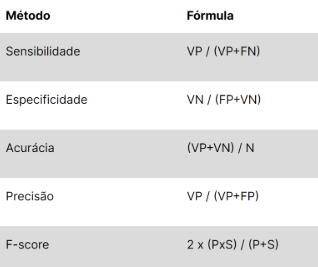


In [1]:
#Carregar bibliotecas e dataset para treinamento
#dataset bem conhecido, números escritos para classificação, principal intuíto é calcular as métricas
from tensorflow.keras import datasets, layers, models
from tensorflow import math, argmax
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

%load_ext tensorboard
logdir = 'log'
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [2]:
#redimensionando as imagens
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

train_images, test_images = train_images / 255.0, test_images / 255.0
classes = [0,1,2,3,4,5,6,7,8,9]

In [3]:
#Treinamento do modelo
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPool2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPool2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_images, train_labels, epochs=5, validation_data=(test_images, test_labels))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 32ms/step - accuracy: 0.8939 - loss: 0.3350 - val_accuracy: 0.9849 - val_loss: 0.0426
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 32ms/step - accuracy: 0.9848 - loss: 0.0500 - val_accuracy: 0.9883 - val_loss: 0.0355
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9903 - loss: 0.0322 - val_accuracy: 0.9901 - val_loss: 0.0320
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 31ms/step - accuracy: 0.9916 - loss: 0.0254 - val_accuracy: 0.9880 - val_loss: 0.0368
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 32ms/step - accuracy: 0.9942 - loss: 0.0178 - val_accuracy: 0.9914 - val_loss: 0.0265


In [4]:
y_true = test_labels
y_pred = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


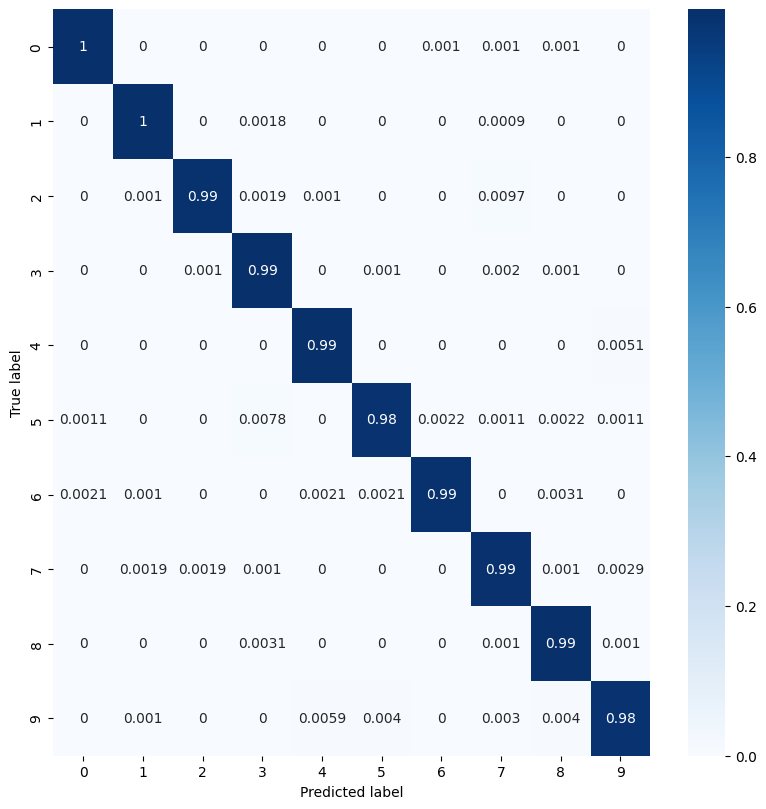

In [5]:
#Montando matriz de confusão
predicted_labels = argmax(y_pred, axis=1)
con_mat = math.confusion_matrix(labels=y_true,predictions=predicted_labels).numpy()
con_mat_norm = np.around(con_mat.astype('float') / con_mat.sum(axis=1)[:, np.newaxis], decimals=4)

con_mat_df = pd.DataFrame(con_mat_norm,
                          index = classes,
                          columns = classes)

figure = plt.figure(figsize=(8, 8))
sns.heatmap(con_mat_df, annot=True,cmap=plt.cm.Blues)
plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [33]:
tp_total = 0
fp_total = 0
fn_total = 0
tn_total = 0

for i in range(0, 10):
    tp = con_mat_df.loc[i, i]
    tn = con_mat_df.loc[:, i].sum() - tp
    fn = con_mat_df.loc[i, :].sum() - tp
    tn = con_mat_df.values.sum() - (tp + fp + fn)

    tp_total += tp
    tn_total += tn
    fp_total += fp
    fn_total += fn

print(f"True Positive:  {tp_total:.2f}")
print(f"True Negative:  {tn_total:.2f}")
print(f"False Positive:  {fp_total:.2f}")
print(f"False Negative:  {fn_total:.2f}")


accuray = (tp_total + tn_total) / (tp_total + tn_total + fp_total + fn_total)
precicion = tp_total / (tp_total + fp_total)
recall = tp_total / (tp_total + fn_total)
f1_score = 2 * (precicion * recall) / (precicion + recall)

print(f"Accuracy:  {accuray:.2f}")
print(f"Precicion:  {precicion:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1_score:.2f}")

True Positive:  9.91
True Negative:  90.00
False Positive:  0.00
False Negative:  0.09
Accuracy:  1.00
Precicion:  1.00
Recall: 0.99
F1 Score: 1.00


## 📈 Resultados do Modelo de Classificação

Abaixo estão as métricas extraídas da matriz de confusão e das medidas derivadas:

- **True Positive (VP): 9.91**
  - O modelo identificou corretamente 9.91 casos da classe positiva.
  
- **True Negative (VN): 90.00**
  - Todos os 90 casos negativos foram corretamente classificados.

- **False Positive (FP): 0.00**
  - Nenhum caso negativo foi incorretamente classificado como positivo. Excelente para aplicações que exigem alta **precisão**.

- **False Negative (FN): 0.09**
  - Apenas 0.09 casos positivos foram ignorados pelo modelo. Mostra alta **sensibilidade**.

---

### 🔢 Métricas Derivadas

- **Accuracy: 1.00**
  - O modelo acertou 100% das classificações. Como há baixo desbalanceamento, essa métrica é confiável neste caso.

- **Precisão (Precision): 1.00**
  - Entre todas as previsões positivas, 100% estavam corretas.  
  - Nenhum falso positivo foi cometido, o que é ideal em contextos com alto custo para alarmes falsos.

- **Sensibilidade (Recall): 0.99**
  - O modelo detectou 99% dos casos positivos.  
  - Excelente quando se deseja minimizar **falsos negativos**, como em diagnósticos de doenças.

- **F1 Score: 1.00**
  - Equilíbrio perfeito entre precisão e recall.  
  - Ideal para cenários onde ambos os tipos de erro (FP e FN) importam.

---

### ✅ Conclusão

O modelo apresenta **desempenho praticamente perfeito**, com:
- Zero falsos positivos,
- Um número insignificante de falsos negativos,
- E métricas principais (acurácia, precisão e F1-score) no valor máximo.

🔍 Isso sugere que o modelo está altamente confiável tanto para detectar casos positivos quanto para evitar alarmes falsos.

